# Likelihood function

The likelihood function is given by:

$$
\mathcal L(\mu, b) = \frac{(\mu s + b)^{n}}{n!} e^{-(\mu s + b)} \frac{(\tau b)^{m}}{m!} e^{-(\tau b)}
$$

Check the validity of the asymptotic formulae for the test statistic $q_\mu$ taken from arXiv:1007.1727.

The testing numbers taken from the paper are:
- $b = 9$
- $s = 6$
- $\tau = 1$

In [1]:
# Read the inputs.
import numpy as np
s = np.array([6, 0])
tau = 1
b = 9
b = np.array([b, tau * b])
mu = 1
mu_prime = 0
init_theta = np.array([b[0]])
n_obs = None # if None, no observations are used throughout the notebook
# n_obs = np.array([51, 45000])

In [2]:
import numpy as np
import scipy.special

def log_likelihood_factory(s, n, tau = 1.):
    """
    Factory for the log-likelihood function.
    The returned function takes a single argument, which is a list of parameters.

    Parameters:
    s: expected signal count in the regions (s[0] corresponds to the signal region, s[1] corresponds to the control region)
    n: observed count in the regions (n[0] corresponds to the signal region, n[1] corresponds to the control region)
    tau: ratio of the expected background count in the control region to the expected background count in the signal region
    """

    # theta[0] corresponds to the POI mu, and theta[1:] correspond to the nuisance parameters.
    def log_likelihood(params):
        mu = params[0]
        b  = params[1]
        b = np.array([b, tau * b])
        t = mu * s + b
        nll = -2 * np.sum(n * np.log(t) - t)
        # nll += 2 * np.sum(scipy.special.gammaln(n + 1))
        return nll
        
    return log_likelihood

Find the minimum of the likelihood function with respect to the model parameters.

In [3]:
from iminuit import Minuit

def find_minimum(nll, mu, init_theta, fix_mu = False):
    minuit = Minuit(nll, [mu] + list(init_theta))
    if fix_mu:
        minuit.fixed[0] = True
    minuit.migrad()
    minuit.hesse()

    # Return the value at the minimum and the uncertainty on that value.
    return minuit.values[0], minuit.errors[0], minuit.fval


We have functions to compute the estimator $\hat{\mu}$ and its uncertainty.
As the next step, we will define the test statistic, which is:
$$q_\mu = \begin{cases} 0 & \text{if } \hat{\mu} > \mu \\
        -2 \ln \lambda(\mu) & \text{if } \hat{\mu} \leq \mu
\end{cases}$$
where
$$
-2 \ln \lambda(\mu) = -2 \ln \frac{L(\mu, \hat{\hat{\theta}}(\mu))}{L(\hat{\mu}, \hat{\theta})}
$$

In [4]:
# The test statistic.
def test_statistic(nll, mu, init_theta):

    # Minimizer.
    minuit = Minuit(nll, [mu] + list(init_theta))

    # Global minimum.
    minuit.migrad()
    minuit.hesse()
    mu_hat = minuit.values[0]

    # Return zero if mu_hat > mu.
    if mu_hat > mu:
        return 0
    
    # Denominator - evaluate the nll function at the global minimum.
    global_min = minuit.fval

    # Nominator.
    minuit = Minuit(nll, [mu] + list(init_theta))
    minuit.fixed[0] = True
    minuit.migrad()
    minuit.hesse()
    constraint_min = minuit.fval

    return constraint_min - global_min

# Asimov dataset for the signal hypothesis

Prepare the dataset, setting
$$
n^{\text{A,s}} = \mu s + b
$$

In [5]:
if n_obs is not None:
    # Estimate the hat_hat_b(mu) value, first.
    nll = log_likelihood_factory(s, n_obs, tau = tau)

    from iminuit import Minuit
    minuit = Minuit(nll, [mu] + list(init_theta))
    minuit.fixed[0] = True
    minuit.migrad()
    minuit.hesse()
    hat_hat_b_as = minuit.values[1]
    print(f'Estimated hat_hat_b(mu): {hat_hat_b_as}')

    # Asimov dataset
    n_as = mu * s + hat_hat_b_as

else:
    # Asimov dataset
    n_as = mu * s + b

nll_as = log_likelihood_factory(s, n_as, tau = tau)

Generate pseudo-experiments to confirm the chi2 distribution of the test statistic.

In [6]:
# Generate the pseudo-experiments.
def generate_pseudo_experiments(mu, s, nu, tau, n_toys = 1000):
    pseudo_experiments = np.random.poisson(nu, size=(n_toys, len(nu)))

    ts_toys = []
    for i in range(n_toys):
        pseudo_n = pseudo_experiments[i]
        nll = log_likelihood_factory(s, pseudo_n, tau = tau)
        ts = test_statistic(nll, mu, init_theta)
        ts_toys.append(ts)

    return np.array(ts_toys)

ts_toys = generate_pseudo_experiments(mu, s, n_as, tau)

/tmp/ipykernel_11350/644937118.py:21: RuntimeWarning: invalid value encountered in log
  nll = -2 * np.sum(n * np.log(t) - t)


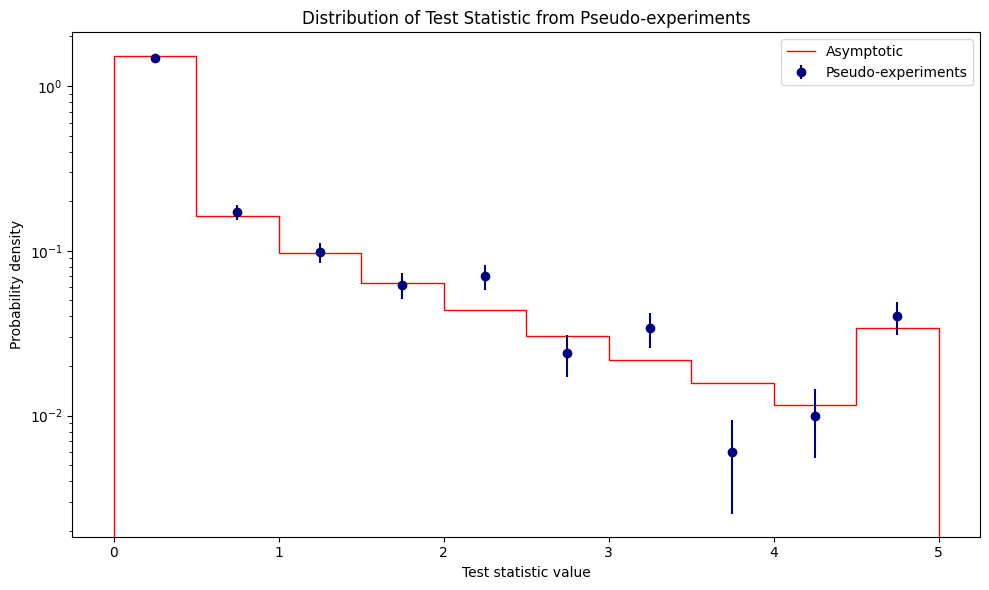

Chi-squared value: 16.652031473056123
Chi-squared test p-value: 0.08242705573404595


In [ ]:
# plot the histogram of the test statistic values from the pseudo-experiments.
# Also plot the half-chi-square distribution with 1 degree of freedom as a histogram.
# Half chi-square distribution is the sum of two parts: a delta function at zero with weight 0.5, and a chi-square distribution with 1 degree of freedom with weight 0.5.
import matplotlib.pyplot as plt
from scipy.stats import chi2
n_bins = 10
upper_bound = 5
n_toys = len(ts_toys)
plt.figure(figsize=(10, 6))
# split the interval [0, upper_bound] into n_bins bins, and plot the histogram of the test statistic values from the pseudo-experiments in these bins, normalized to form a probability density.
# add the events with test statistic value above the upper_bound to the last bin.
bin_edges = np.linspace(0, upper_bound, n_bins + 1)
bin_width = bin_edges[1] - bin_edges[0]
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
histogram, _ = np.histogram(ts_toys, bins=bin_edges)
histogram[0] += np.sum(ts_toys < 0)
histogram[-1] += np.sum(ts_toys > upper_bound)  # Add the events with test statistic value above the upper_bound to the last bin.
h_unc = np.sqrt(histogram)  # Uncertainty on the histogram counts.
histogram = histogram / (n_toys * bin_width)  # Normalize the histogram to form a probability density.
h_unc = h_unc / (n_toys * bin_width)
plt.errorbar(bin_centers, histogram, yerr=h_unc, fmt='o', color='navy', label='Pseudo-experiments')

# Prepare the histogram of the half chi-square distribution.
# For this, evaluate the chi-square cdf at the bin edges, and take the difference to get the probability for each bin. Then, multiply by 0.5 to get the half chi-square distribution.
half_chi2_hist = 0.5 * (- chi2.sf(bin_edges[1:], df=1) + chi2.sf(bin_edges[:-1], df=1))
half_chi2_hist /= bin_width  # Normalize by the bin width to get the probability density.
half_chi2_hist[0] += 0.5 / bin_width  # Add the delta function at zero.
half_chi2_hist[-1] += 0.5 * chi2.sf(upper_bound, df=1) / bin_width  # Add the tail above the upper bound to the last bin.
# plt.step(bin_centers, half_chi2_hist, where='mid', label='Half chi-square distribution (1 dof)', color='red')
plt.stairs(half_chi2_hist, bin_edges, fill = False, label='Asymptotic', color='red')
plt.xlabel('Test statistic value')
plt.ylabel('Probability density')
plt.yscale('log')
plt.title('Distribution of Test Statistic from Pseudo-experiments')
plt.legend()
plt.tight_layout()
plt.show()

# Evaluate the chi-square goodness of fit test for the histogram of the test statistic values from the pseudo-experiments, comparing it to the half chi-square distribution with 1 degree of freedom.
# For this, evaluate the expected number of pseudo-experiments in each bin according to the half chi-square distribution, and compare it to the observed number of pseudo-experiments in each bin.
observed_counts = histogram * n_toys * bin_width
expected_counts = half_chi2_hist * n_toys * bin_width
chi_squared_value = np.sum((observed_counts - expected_counts) ** 2 / expected_counts)
print(f'Chi-squared value: {chi_squared_value}')
# Calculate the p-value for the chi-square test with the appropriate number of degrees of freedom, which is the number of bins.
p_value = chi2.sf(chi_squared_value, df=n_bins)
print(f'Chi-squared test p-value: {p_value}')

# Asimov dataset for the background-only hypothesis

Prepare the dataset, setting
$$
n_i^{\text{A,b}} = \mu' s_i + b_i
$$

In [8]:
if n_obs is not None:
    # Estimate the hat_hat_b(mu') value, first.
    nll = log_likelihood_factory(s, n_obs, tau = tau)

    from iminuit import Minuit
    minuit = Minuit(nll, [mu_prime] + list(init_theta))
    minuit.fixed[0] = True
    minuit.migrad()
    minuit.hesse()
    hat_hat_b_ab = minuit.values[1]
    print(f'Estimated hat_hat_b(mu\'): {hat_hat_b_ab}')

    # Asimov dataset
    n_ab = mu_prime * s + hat_hat_b_ab

else:
    # Asimov dataset
    n_ab = mu_prime * s + b
    
nll_ab = log_likelihood_factory(s, n_ab, tau = tau)

Generate pseudo-experiments and compare the resulting distribution to the asymptotic formula.
The cumulative distribution function corresponding to the asymptotic density is given by:
$$
F(q_\mu | \mu') = \Phi\left(\sqrt{q_\mu} - \frac{\mu - \mu'}{\sigma}\right),
$$
where $\Phi$ is the cumulative distribution function of the standard normal distribution, and $\sigma$ is the standard deviation of the estimator $\hat{\mu}$ under the background-only hypothesis.

See Eq. (57) in https://arxiv.org/pdf/1007.1727.pdf.

In [9]:
ts_toys = generate_pseudo_experiments(mu, s, n_ab, tau)

/tmp/ipykernel_11350/644937118.py:21: RuntimeWarning: invalid value encountered in log
  nll = -2 * np.sum(n * np.log(t) - t)


integral of the asymptotic distribution: 1.0
integral of the histogram: 1.0


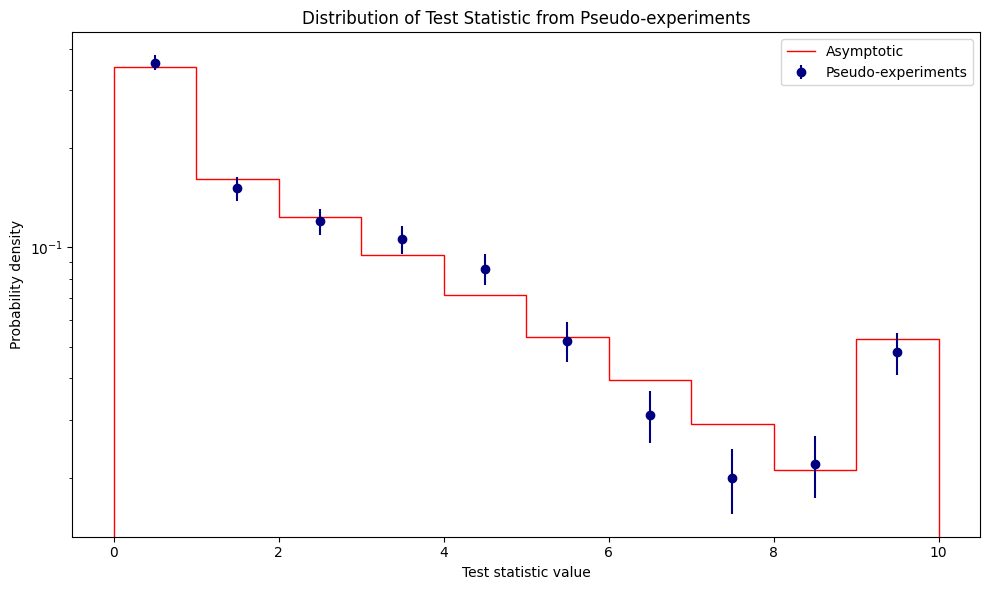

Chi-squared value: 10.59996120988966
Chi-squared test p-value: 0.38952140229569177


In [10]:
# plot the histogram of the test statistic values from the pseudo-experiments.
# Also plot the half-chi-square distribution with 1 degree of freedom as a histogram.
# Half chi-square distribution is the sum of two parts: a delta function at zero with weight 0.5, and a chi-square distribution with 1 degree of freedom with weight 0.5.
import matplotlib.pyplot as plt
from scipy.stats import norm
n_bins = 10
upper_bound = 10
plt.figure(figsize=(10, 6))
# split the interval [0, upper_bound] into n_bins bins, and plot the histogram of the test statistic values from the pseudo-experiments in these bins, normalized to form a probability density.
# add the events with test statistic value above the upper_bound to the last bin.
bin_edges = np.linspace(0, upper_bound, n_bins + 1)
bin_width = bin_edges[1] - bin_edges[0]
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
histogram, _ = np.histogram(ts_toys, bins=bin_edges)
histogram[0] += np.sum(ts_toys < 0)
histogram[-1] += np.sum(ts_toys > upper_bound)
h_unc = np.sqrt(histogram)  # Uncertainty on the histogram counts.
histogram = histogram / (n_toys * bin_width)  # Normalize the histogram to form a probability density.
h_unc = h_unc / (n_toys * bin_width)
# plt.stairs(histogram, bin_edges, fill=True, color='skyblue', edgecolor='navy', alpha=0.7)
plt.errorbar(bin_centers, histogram, yerr=h_unc, fmt='o', color='navy', label='Pseudo-experiments')

# Prepare the histogram of the asymptotic distribution integrals over the bins.
# Start with the sigma parameter evaluation.
ts_ab = test_statistic(nll_ab, mu, init_theta)
sigma_ab = np.sqrt((mu - mu_prime) ** 2 / ts_ab)
shift = (mu - mu_prime) / sigma_ab
half_chi2_hist = (norm.cdf(np.sqrt(bin_edges[1:]) - shift) - norm.cdf(np.sqrt(bin_edges[:-1]) - shift))
half_chi2_hist[0] += norm.cdf(-shift)  # Add the delta function at zero.
half_chi2_hist[-1] += norm.sf(np.sqrt(upper_bound) - shift) # Add the tail above the upper bound to the last bin.
half_chi2_hist /= bin_width  # Normalize by the bin width to get the probability density.
print(f'integral of the asymptotic distribution: {np.sum(half_chi2_hist * bin_width)}')
print(f'integral of the histogram: {np.sum(histogram * bin_width)}')
plt.stairs(half_chi2_hist, bin_edges, fill = False, label='Asymptotic', color='red')
plt.xlabel('Test statistic value')
plt.ylabel('Probability density')
plt.yscale('log')
plt.title('Distribution of Test Statistic from Pseudo-experiments')
plt.legend()
plt.tight_layout()
plt.show()

# Evaluate the chi-square goodness of fit test for the histogram of the test statistic values from the pseudo-experiments, comparing it to the half chi-square distribution with 1 degree of freedom.
# For this, evaluate the expected number of pseudo-experiments in each bin according to the half chi-square distribution, and compare it to the observed number of pseudo-experiments in each bin.
observed_counts = histogram * n_toys * bin_width
expected_counts = half_chi2_hist * n_toys * bin_width
chi_squared_value = np.sum((observed_counts - expected_counts) ** 2 / expected_counts)
print(f'Chi-squared value: {chi_squared_value}')
# Calculate the p-value for the chi-square test with the appropriate number of degrees of freedom, which is the number of bins minus 1.
p_value = chi2.sf(chi_squared_value, df=n_bins)
print(f'Chi-squared test p-value: {p_value}')

# Non-centrality parameter

Under the assumption that $\mu = \mu'$, the test statistic $q_\mu$ is distributed as a non-central chi-square distribution with one degree of freedom and non-centrality parameter $\Lambda$.
The $\Lambda$ parameter can be estimated using the Asimov dataset, $n_i^\text{A} = \mu' s_i + b_i + \hat{\hat{\theta}}_i(\mu')$, and the following formulae:

$$
C^{-1}_{ij} = - \frac{\partial^2 \ln \mathcal L_\mathrm{S}^\text{A}}{\partial \theta_i \partial \theta_j} = \frac{1}{2} \frac{\partial^2 (-2 \ln \mathcal L_\mathrm{S}^\text{A})}{\partial \theta_i \partial \theta_j},
$$
where
$$
C^{-1}_{ij} = \text{cov}(\theta_i, \theta_j)
$$
and $\theta_0 = \mu'$, and $\theta_i = \hat{\hat{\theta}}_i(\mu')$ for $i \geq 1$.

$$
\Lambda = \frac{(\mu - \mu')^2}{\sigma^2} = q_\mu^\text{A}
$$
where $\sigma^2 = \text{cov}(\mu, \mu) = C_{00}$.

See Eq. (28) in https://arxiv.org/abs/1007.1727

In [11]:
# Eq. 30 from arXiv:1007.1727
ts_ab = test_statistic(nll_ab, mu, init_theta)
sigma_ab = np.sqrt((mu - mu_prime) ** 2 / ts_ab)
print("Eq. 30:", sigma_ab)

# Evaluate the second derivative wrt. the mu parameter numerically.
epsilon = 1e-3
init_b = b[0]
if n_obs is not None:
    init_b = hat_hat_b_ab
f_mp = nll_ab([mu_prime + epsilon] + list([init_b]))
f_mm = nll_ab([mu_prime - epsilon] + list([init_b]))
f_0  = nll_ab([mu_prime          ] + list([init_b]))
second_derivative = (f_mp - 2 * f_0 + f_mm) / epsilon ** 2
inv_variance_ab = second_derivative / 2
variance_ab = 1 / inv_variance_ab
sigma_ab = np.sqrt(variance_ab)
print("By-hand numerical differentiation:", sigma_ab)

# Use the hessian from the minimizer to evaluate the variance.
minuit = Minuit(nll_ab, [mu_prime] + list([init_b]))
# minuit.fixed[0] = True
minuit.migrad()
minuit.hesse()
variance_ab = minuit.covariance[0, 0]
sigma_ab = np.sqrt(variance_ab)
print(f'mu_hat: {minuit.values[0]}, b_hat: {minuit.values[1]}')
print("Using hessian:", sigma_ab)

Eq. 30: 0.724983617735701
By-hand numerical differentiation: 0.49999994445391355
mu_hat: 0.0, b_hat: 9.0
Using hessian: 0.7070542905864011


Check that the assumption of the non-central chi-square distribution is valid by comparing the distribution of the test statistic from the pseudo-experiments with the theoretical distribution.

In [12]:
# Generate the pseudo-experiments from the Asimov dataset, which is given by n = b, and evaluate the test statistic for each pseudo-experiment. Then, plot the histogram of the test statistic values from the pseudo-experiments, and compare it to the asymptotic distribution.


# CLs value calculation

We know that:

- The test statistic distribution under the signal hypothesis $\mu$ is the chi-squared distribution with 1 degree of freedom.

- The test statistic distribution under the background-only hypothesis $\mu' = 0$ is the non-central chi-squared distribution with 1 degree of freedom and non-centrality parameter $\Lambda = (\mu - \mu')^2 / \sigma^2 = \mu^2 / \sigma^2$

The CLs value can be calculated as:
$$
CLs = \frac{p_{\text{signal}}}{p_{\text{background}}}
$$
where $p_{\text{signal}}$ ($p_{\text{background}}$) is the p-value under the signal (background-only) hypothesis.

In [13]:
from scipy.stats import chi2, ncx2
from scipy.stats import norm

def p_value_bkg(s, n, b, V, mu):

    nll = log_likelihood_factory(s, n, b, V)
    observed_ts = test_statistic(nll, mu, init_theta)

    # p_bkg calculation
    nll_a = log_likelihood_factory(s, b, b, V)
    _, sigma, _ = find_minimum(nll_a, 0, init_theta)
    p_bkg = ncx2.sf(observed_ts, df = 1, nc = mu ** 2 / sigma ** 2)

    return p_bkg

def cls(s, n, b, V, mu, n_sigma = None):
    """Calculate the CLs value.

    mu: signal hypothesis
    n_sigma: number of standard deviations for expected limits; if None, calculate the observed CLs; if a number, calculate the expected CLs for that number of standard deviations.
    """
    nll = log_likelihood_factory(s, n, b, V)
    observed_ts = test_statistic(nll, mu, init_theta)

    # calculate the sigma for the non-centrality parameter
    nll_a = log_likelihood_factory(s, b, b, V)
    _, sigma, _ = find_minimum(nll_a, 0, init_theta)
    observed_ts_a = test_statistic(nll_a, mu, init_theta)
    print(_, sigma)
    print(observed_ts, observed_ts_a)

    # non-centrality parameter for the background-only hypothesis
    nc = mu ** 2 / sigma ** 2
    nc = test_statistic(nll_a, mu, init_theta)

    # shift the observed test statistic if n_sigma is not None
    if n_sigma is not None:
        # For expected limits, we evaluate the median of the background-only test statistic distribution, and the quantiles corresponding to the n_sigma standard deviations, as the observed test statistic value.
        probability = norm.cdf(n_sigma)
        observed_ts = ncx2.ppf(probability, df = 1, nc = nc)
        # Just a check.
        if n_sigma == 0:
            print(observed_ts, observed_ts_a, (observed_ts - observed_ts_a) / observed_ts_a)

    # p-values
    p_bkg = ncx2.sf(observed_ts, df = 1, nc = nc)
    p_sig = chi2.sf(observed_ts, df = 1)

    return p_sig / p_bkg

In [14]:
# print(cls(s, np.int64(b), np.int64(b), V, mu = 0, n_sigma = 0))

# Hypothesis test inversion

- Scan over the parameter $\theta$ values and compute the p-value for each of them.

- Plot the p-value as a function of $\theta$.

- Linearly interpolate the p-value curve to find the value of $\theta$ for which the p-value is equal to 0.05. This will give us the 95% confidence level upper limit on $\theta$.

In [15]:
# # Do a hypothesis test inversion to find the 95% confidence level upper limit on the parameter $\theta$.
# # Scan over the parameter $\theta$ values and compute the p-value for each of them, using the theoretical distribution of the test statistic under the null hypothesis (chi-squared distribution with 1 degree of freedom).
# # Plot the p-value as a function of $\theta$.
# # Linearly interpolate the p-value curve to find the value of $\theta$ for which the p-value is equal to 0.05. This will give us the 95% confidence level upper limit on $\theta$.

# import numpy as np
# from scipy.stats import chi2

# mu_values = np.linspace(0, 10, 10)
# p_values = []
# cls_values = []
# p_values_bkg = []
# nll = log_likelihood_factory(s, n, b, V)
# for mu_val in mu_values:
#     observed_ts = test_statistic(nll, mu_val, init_theta)
#     p_values.append(chi2.sf(observed_ts, df=1))
#     cls_values.append(cls(s, n, b, V, mu_val))
#     p_values_bkg.append(p_value_bkg(s, n, b, V, mu_val))


In [16]:
# # Plot the p-value as a function of mu:
# import matplotlib.pyplot as plt
# plt.plot(mu_values, p_values, marker='o', label='p')
# plt.plot(mu_values, p_values_bkg, marker='s', label='p_bkg')
# plt.plot(mu_values, cls_values, marker='^', label='CLs')
# plt.axhline(0.05, color='red', linestyle='dashed', label='p-value = 0.05')
# plt.xlabel(r'$\mu$')
# plt.ylabel('P-value')
# plt.title('P-value as a function of mu')
# plt.ylim(0, 1)
# plt.legend()
# plt.show()

# Expected limits

- The expected limit is calculated by using the asimov dataset, which is the dataset that corresponds to the background-only prediction.

- The $\pm 1\sigma$ and $\pm 2\sigma$ expected limits can be calculated by using the asimov dataset and evaluating the quantile of the test statistic distribution under the background-only hypothesis that corresponds to the desired n_sigma value.

In [17]:
# limits = {n_sigma: [] for n_sigma in [-2, -1, 0, 1, 2]} # will have n_sigma as keys
# asimov = b
# for mu_val in mu_values:
#     for n_sigma in [-2, -1, 0, 1, 2]:
#         cls_value = cls(s, n, b, V, mu_val, n_sigma = n_sigma)
#         limits[n_sigma].append(cls_value)

In [18]:
# # Draw the expected limit as a black dashed line.
# # Draw the +- 1 sigma and +/- 2 sigma expected limits as green and yellow bands, respectively.
# # Draw the observed CLs values as a black solid line.
# plt.plot(mu_values, limits[0], color='black', linestyle='dashed', label='Expected limit')
# plt.fill_between(mu_values, limits[-1], limits[1], color='green', alpha=0.5, label='Expected limit ± 1σ')
# plt.fill_between(mu_values, limits[-2], limits[2], color='yellow', alpha=0.5, label='Expected limit ± 2σ')
# plt.plot(mu_values, cls_values, color='black', label='Observed CLs')
# plt.axhline(0.05, color='red', linestyle='dashed', label='p-value = 0.05')
# plt.xlabel(r'$\mu$')
# plt.ylabel('CLs')
# plt.title('CLs as a function of mu')
# plt.legend()
# plt.show()

# Upper limit on the signal strength

- The upper limit on the signal strength $\theta$ is the value of $\theta$ for which the p-value is equal to 0.05, as calculated in the hypothesis test inversion step.

- The present algorithm:

1. Go through the list of CLs values, starting from the highest index.
2. Check if the CLs value is less than 0.05.
3. If yes, then check if the next CLs value (at index lower by 1) is greater than 0.05.
4. If yes, then perform linear interpolation between these two points to find the value of $\theta$ for which the CLs value is equal to 0.05. This will give us the upper limit on $\theta$ at 95% confidence level.

In [19]:
# def find_upper_limit(mu_values, cls_values):
#     upper_limit = None
#     i = len(mu_values) - 1
#     while i > 0 and cls_values[i] < 0.05:
#         if cls_values[i - 1] > 0.05:
#             # Perform the linear interpolation.
#             theta1 = mu_values[i - 1]
#             theta2 = mu_values[i]
#             cls1 = cls_values[i - 1]
#             cls2 = cls_values[i]
#             upper_limit = theta1 + (0.05 - cls1) * (theta2 - theta1) / (cls2 - cls1)
#         i -= 1
#     return upper_limit

# obs_limit = find_upper_limit(mu_values, cls_values)
# exp_limit = find_upper_limit(mu_values, limits[0])
# print(f"Observed upper limit on theta at 95% CL: {obs_limit}")
# print(f"Expected upper limit on theta at 95% CL: {exp_limit}")
# for n_sigma in [-2, -1, 0, 1, 2]:
#     limit = find_upper_limit(mu_values, limits[n_sigma])
#     print(f"Expected upper limit on theta at 95% CL for n_sigma={n_sigma}: {limit}")